t: 0.004 [s], Average temperature: 23.64 Celcius


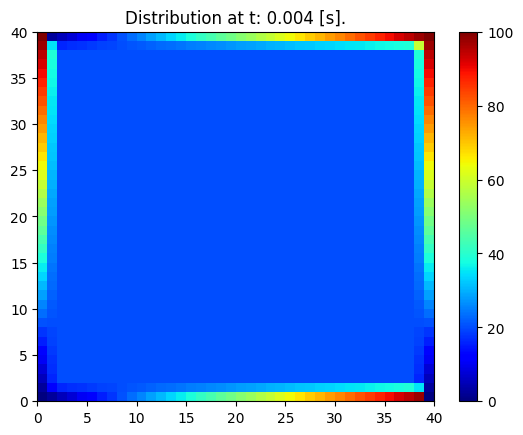

t: 0.007 [s], Average temperature: 24.16 Celcius
t: 0.011 [s], Average temperature: 24.60 Celcius
t: 0.015 [s], Average temperature: 24.97 Celcius
t: 0.019 [s], Average temperature: 25.31 Celcius
t: 0.022 [s], Average temperature: 25.61 Celcius
t: 0.026 [s], Average temperature: 25.90 Celcius
t: 0.030 [s], Average temperature: 26.16 Celcius
t: 0.034 [s], Average temperature: 26.41 Celcius
t: 0.037 [s], Average temperature: 26.64 Celcius
t: 0.041 [s], Average temperature: 26.86 Celcius
t: 0.045 [s], Average temperature: 27.08 Celcius
t: 0.049 [s], Average temperature: 27.28 Celcius
t: 0.052 [s], Average temperature: 27.47 Celcius
t: 0.056 [s], Average temperature: 27.66 Celcius
t: 0.060 [s], Average temperature: 27.84 Celcius
t: 0.064 [s], Average temperature: 28.02 Celcius
t: 0.067 [s], Average temperature: 28.19 Celcius
t: 0.071 [s], Average temperature: 28.35 Celcius
t: 0.075 [s], Average temperature: 28.51 Celcius
t: 0.078 [s], Average temperature: 28.66 Celcius
t: 0.082 [s], Averag

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Defining our problem

a = 110
length = 50 #mm
time = 4 #seconds
nodes = 40

# Initialization

dx = length / (nodes-1)
dy = length / (nodes-1)

dt = min(   dx**2 / (4 * a),     dy**2 / (4 * a))

t_nodes = int(time/dt) + 1

u = np.zeros((nodes, nodes)) + 20 # Plate is initially as 20 degres C

# Boundary Conditions

u[0, :] = np.linspace(0, 100, nodes)
u[-1, :] = np.linspace(0, 100, nodes)

u[:, 0] = np.linspace(0, 100, nodes)
u[:, -1] = np.linspace(0, 100, nodes)

# Visualizing with a plot

fig, axis = plt.subplots()

pcm = axis.pcolormesh(u, cmap=plt.cm.jet, vmin=0, vmax=100)
plt.colorbar(pcm, ax=axis)

# Simulating

counter = 0

while counter < time :

    w = u.copy()

    for i in range(1, nodes - 1):
        for j in range(1, nodes - 1):

            dd_ux = (w[i-1, j] - 2*w[i, j] + w[i+1, j])/dx**2
            dd_uy = (w[i, j-1] - 2*w[i, j] + w[i, j+1])/dy**2

            u[i, j] = dt * a * (dd_ux + dd_uy) + w[i, j]

    counter += dt

    print("t: {:.3f} [s], Average temperature: {:.2f} Celcius".format(counter, np.average(u)))

    # Updating the plot

    pcm.set_array(u)
    axis.set_title("Distribution at t: {:.3f} [s].".format(counter))
    plt.pause(0.01)


plt.show()